# RFM customer segmentation (K-Means)

**Question:** what distinct types of customers does the retailer have, and how much is each type worth?

**Method:** describe each customer by **R**ecency (days since last order), **F**requency (number of orders) and **M**onetary value (total spend, GBP), standardise the three measures, and group customers with K-Means. The segments feed the *Customer Segmentation* and *Churn Risk* pages of the Power BI report.

In [10]:
# Importing the necessary libraries
import os
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Server and database come from environment variables, so no machine name is hard-coded.
# Set SQL_SERVER (e.g. localhost\SQLEXPRESS) and SQL_DATABASE before running, or keep the defaults.
SQL_SERVER = os.getenv("SQL_SERVER", r"localhost\SQLEXPRESS")
SQL_DATABASE = os.getenv("SQL_DATABASE", "OnlineRetailII")

# Connecting to the SQL Server
connection = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    f"Server={SQL_SERVER};"
    f"Database={SQL_DATABASE};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

## 1. Load the RFM table
Built in SQL by `rpt.calculateRFMtable`: one row per identified customer (5,852). Recency is measured against the latest order date in the dataset, since this is historical data.

In [11]:
# Loading the data
query = "EXEC rpt.calculateRFMtable"
df = pd.read_sql(query, connection)

# Seeing the head of the data
print(df.head(5))
print(df.describe())

C:\Users\psoma\AppData\Local\Temp\ipykernel_15508\438272184.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


   customer_id  Recency  Frequency   Monetary
0        18102        0        145  580987.04
1        14646        1        145  526751.52
2        14156        9        144  303069.88
3        14911        1        373  272252.79
4        17450        8         51  244784.25
        customer_id      Recency    Frequency       Monetary
count   5852.000000  5852.000000  5852.000000    5852.000000
mean   15319.707109   199.732399     6.253247    2916.609242
std     1714.929942   208.523287    12.749286   14306.292958
min    12346.000000     0.000000     1.000000       2.950000
25%    13837.750000    25.000000     1.000000     339.575000
50%    15320.500000    95.000000     3.000000     856.020000
75%    16802.250000   379.000000     7.000000    2241.030000
max    18287.000000   738.000000   373.000000  580987.040000


## 2. Standardise
K-Means works on distances, so the three measures must be on the same scale. A few extreme customers (the scaled Monetary value reaches 40 standard deviations) will end up in their own clusters, which is useful here.

In [12]:
# Standardize the RFM data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df[['Recency', 'Frequency', 'Monetary']])

print("Scaled data sample:\n", rfm_scaled[:5])

Scaled data sample:
 [[-0.95792403 10.88363752 40.41017681]
 [-0.95312799 10.88363752 36.61882746]
 [-0.91475969 10.80519505 20.98229921]
 [-0.95312799 28.76851984 18.82802182]
 [-0.91955573  3.51004568 16.90782577]]


## 3. Choose k: elbow method

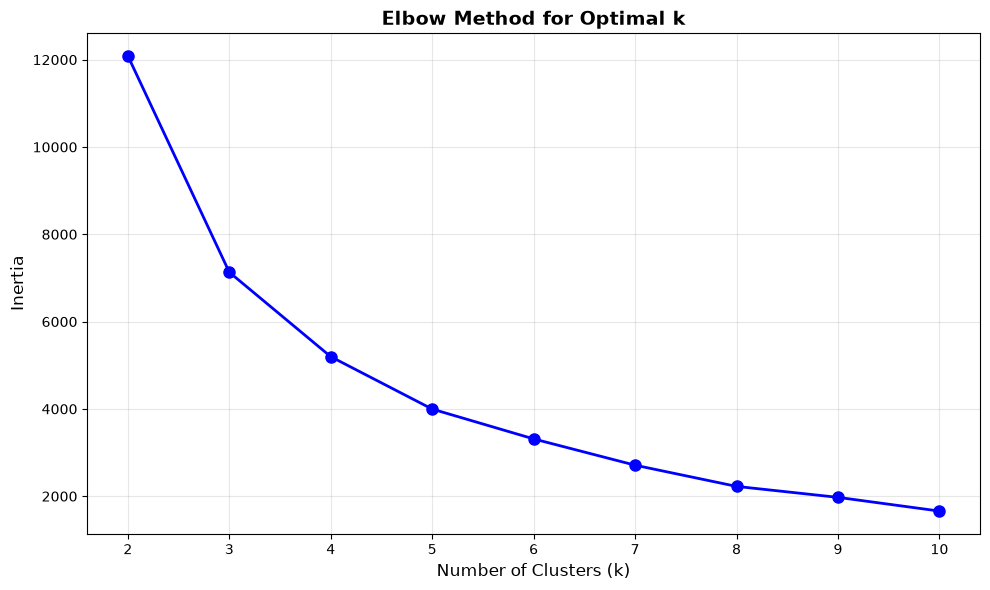

In [13]:
# Test k values from 2 to 10 using Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=1000)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## 4. Choose k: silhouette score

Optimal k by Silhouette Score: 2


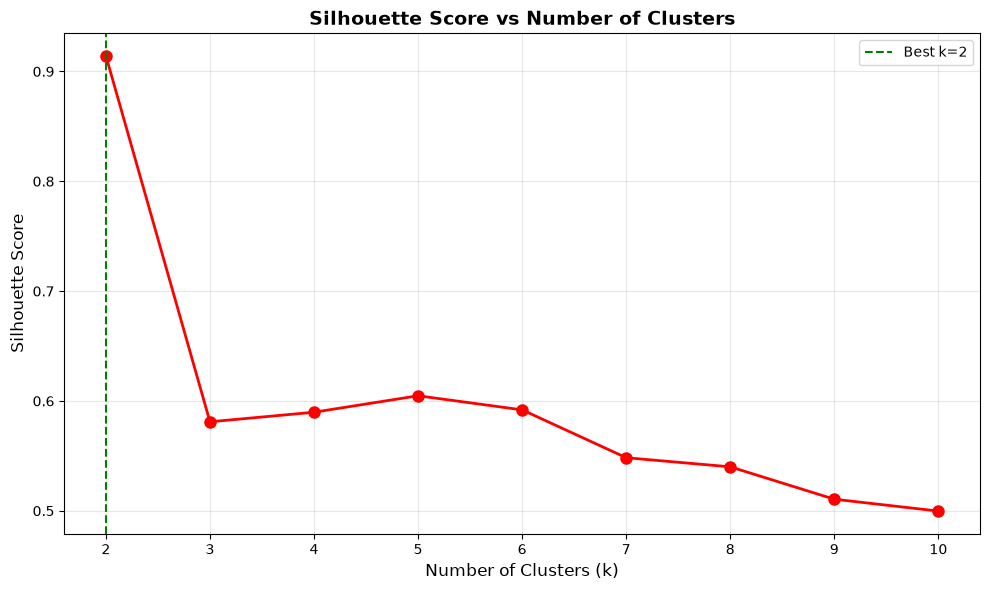

In [14]:
# Finding out the silhouette score
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=1000)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

# Find k with highest silhouette score
optimal_k_silhouette = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"Optimal k by Silhouette Score: {optimal_k_silhouette}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.axvline(x=optimal_k_silhouette, color='g', linestyle='--', label=f'Best k={optimal_k_silhouette}')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Fit the final model (k = 4)
The silhouette score is highest at k = 2, but two groups (high and low value) are too coarse to act on. The elbow bends at k = 4 and the silhouette score there is still acceptable (0.59), so k = 4 is used. This is a judgement call, and it is documented so it can be challenged.

In [15]:
# We choose the optimal k based on business requirements. We considered both the elbow method and the silhouette score:
# - Silhouette score was highest at k=2 (> 0.90)
# - Elbow method suggested k=4 (clear bend in the curve)
# However, we chose k=4 because of the project's business requirements:
#   1. k=2 only gives 2 segments (High-value, Low-value), which are too broad and not actionable
#   2. k=4 gives 4 distinct customer types which allow for targeted marketing strategies per group
#   3. Silhouette score at k=4 (0.59) is still acceptable for business purposes

# Apply K-Means with optimal k
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=1000)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Print cluster distribution in readable format
print("=" * 50)
print("CLUSTER DISTRIBUTION")
print("=" * 50)
cluster_counts = df['Cluster'].value_counts().sort_index()
total_customers = len(df)
for cluster_id, count in cluster_counts.items():
    percentage = (count / total_customers) * 100
    print(f"Cluster {cluster_id}: {count:,} customers ({percentage:.1f}%)")

# Analyze cluster characteristics
print("\n" + "=" * 50)
print("CLUSTER CHARACTERISTICS")
print("=" * 50)

cluster_summary = df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std'])

for cluster_id in range(optimal_k):
    print(f"\nCluster {cluster_id}:")
    print(f"  Recency (days):")
    print(f"    Mean: {cluster_summary.loc[cluster_id, ('Recency', 'mean')]:.1f}")
    print(f"    Median: {cluster_summary.loc[cluster_id, ('Recency', 'median')]:.1f}")
    print(f"    Std Dev: {cluster_summary.loc[cluster_id, ('Recency', 'std')]:.1f}")
    
    print(f"  Frequency (orders):")
    print(f"    Mean: {cluster_summary.loc[cluster_id, ('Frequency', 'mean')]:.1f}")
    print(f"    Median: {cluster_summary.loc[cluster_id, ('Frequency', 'median')]:.1f}")
    print(f"    Std Dev: {cluster_summary.loc[cluster_id, ('Frequency', 'std')]:.1f}")
    
    print(f"  Monetary (£):")
    print(f"    Mean: £{cluster_summary.loc[cluster_id, ('Monetary', 'mean')]:,.2f}")
    print(f"    Median: £{cluster_summary.loc[cluster_id, ('Monetary', 'median')]:,.2f}")
    print(f"    Std Dev: £{cluster_summary.loc[cluster_id, ('Monetary', 'std')]:,.2f}")

CLUSTER DISTRIBUTION
Cluster 0: 3,830 customers (65.4%)
Cluster 1: 1,980 customers (33.8%)
Cluster 2: 4 customers (0.1%)
Cluster 3: 38 customers (0.6%)

CLUSTER CHARACTERISTICS

Cluster 0:
  Recency (days):
    Mean: 66.5
    Median: 40.0
    Std Dev: 67.9
  Frequency (orders):
    Mean: 7.2
    Median: 5.0
    Std Dev: 8.0
  Monetary (£):
    Mean: £2,878.50
    Median: £1,311.42
    Std Dev: £4,836.25

Cluster 1:
  Recency (days):
    Mean: 461.2
    Median: 429.0
    Std Dev: 127.1
  Frequency (orders):
    Mean: 2.2
    Median: 1.0
    Std Dev: 2.4
  Monetary (£):
    Mean: £724.93
    Median: £369.26
    Std Dev: £1,387.05

Cluster 2:
  Recency (days):
    Mean: 2.8
    Median: 1.0
    Std Dev: 4.2
  Frequency (orders):
    Mean: 201.8
    Median: 145.0
    Std Dev: 114.2
  Monetary (£):
    Mean: £420,765.31
    Median: £414,910.70
    Std Dev: £155,790.74

Cluster 3:
  Recency (days):
    Mean: 23.7
    Median: 3.0
    Std Dev: 73.1
  Frequency (orders):
    Mean: 99.1
    Media

## 6. Profile the clusters

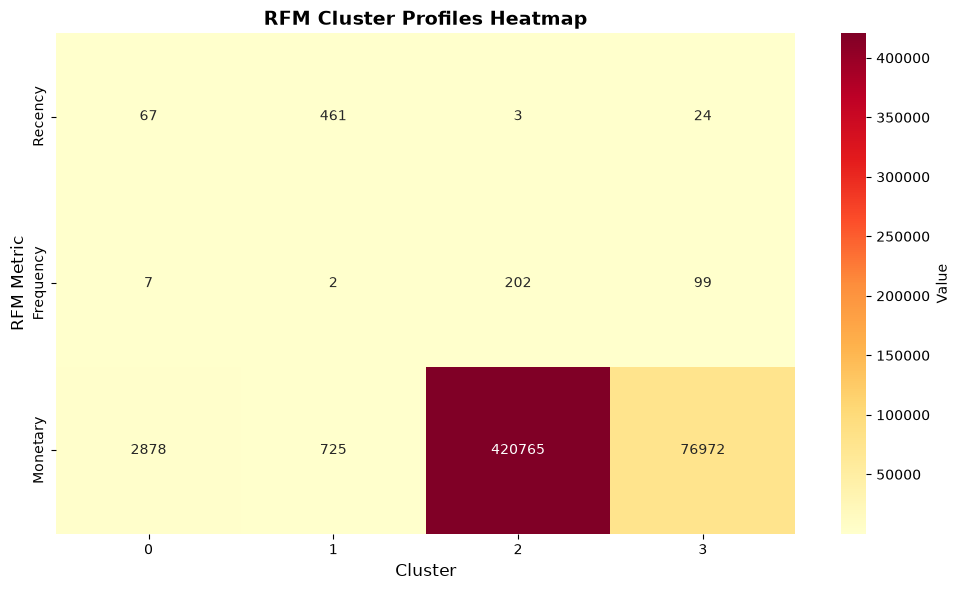

In [16]:
# Heatmap of Cluster Profiles
plt.figure(figsize=(10, 6))
cluster_means = df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
sns.heatmap(cluster_means.T, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Value'})
plt.title('RFM Cluster Profiles Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('RFM Metric', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Name the segments
| Segment | Customers | Profile |
|---|---|---|
| Core / Average | 3,830 (65%) | Recent (about 67 days), about 7 orders, about £2,900 each |
| Churned / Lost | 1,980 (34%) | Inactive for about 461 days, about 2 orders, about £725 each |
| Potential Champions | 38 | Recent (24 days), about 99 orders, about £77,000 each |
| Wholesale / B2B Outliers | 4 | About 202 orders, about £421,000 each |

Forty-two customers (under 1% of the base) hold about 27% of identified revenue, so the segment sizes are very uneven. The names are interpretations of each cluster's profile, not outputs of the algorithm.

In [17]:
# Interpret the clusters and assign business labels
cluster_profiles = {
    0: "Core / Average Customers",     # largest cluster (~3,830)
    1: "Churned / Lost Customers",     # high recency, low frequency and monetary (~1,980)
    2: "Wholesale / B2B Outliers",     # extreme frequency and monetary (4 customers)
    3: "Potential Champions"           # high frequency and monetary, recent (~38)
}

df['Segment'] = df['Cluster'].map(cluster_profiles)

print("\nSegment Summary:")
for cluster_id, segment_name in cluster_profiles.items():
    segment_data = df[df['Cluster'] == cluster_id]
    print(f"\n{segment_name} (Cluster {cluster_id}):")
    print(f"  Count: {len(segment_data)}")
    print(f"  Avg Recency: {segment_data['Recency'].mean():.0f} days")
    print(f"  Avg Frequency: {segment_data['Frequency'].mean():.1f} orders")
    print(f"  Avg Monetary: £{segment_data['Monetary'].mean():.2f}")


Segment Summary:

Core / Average Customers (Cluster 0):
  Count: 3830
  Avg Recency: 67 days
  Avg Frequency: 7.2 orders
  Avg Monetary: £2878.50

Churned / Lost Customers (Cluster 1):
  Count: 1980
  Avg Recency: 461 days
  Avg Frequency: 2.2 orders
  Avg Monetary: £724.93

Wholesale / B2B Outliers (Cluster 2):
  Count: 4
  Avg Recency: 3 days
  Avg Frequency: 201.8 orders
  Avg Monetary: £420765.31

Potential Champions (Cluster 3):
  Count: 38
  Avg Recency: 24 days
  Avg Frequency: 99.1 orders
  Avg Monetary: £76972.08


## 8. Save the segments for Power BI
Writes each customer's cluster and segment name to `rpt.customer_segments`.

In [20]:
from sqlalchemy import create_engine

engine = create_engine(
    f"mssql+pyodbc://{SQL_SERVER}/{SQL_DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

rfm_out = df[['customer_id', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']]
print(rfm_out.head())

rfm_out.to_sql('customer_segments', engine, schema='rpt', if_exists='replace', index=False)

   customer_id  Recency  Frequency   Monetary  Cluster  \
0        18102        0        145  580987.04        2   
1        14646        1        145  526751.52        2   
2        14156        9        144  303069.88        2   
3        14911        1        373  272252.79        2   
4        17450        8         51  244784.25        3   

                    Segment  
0  Wholesale / B2B Outliers  
1  Wholesale / B2B Outliers  
2  Wholesale / B2B Outliers  
3  Wholesale / B2B Outliers  
4       Potential Champions  


268